In [2]:
# Load the AzureML Open Datasets Diabetes dataset
from azureml.opendatasets import Diabetes

diabetes = Diabetes.get_tabular_dataset()
diabetes_df = diabetes.to_pandas_dataframe()

print('Shape:', diabetes_df.shape)
print('Columns:', list(diabetes_df.columns))
diabetes_df.head()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
Shape: (442, 11)
Columns: ['AGE', 'SEX', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'Y']


,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [3]:
# Decision Tree (regression) from scratch
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, List, Tuple


@dataclass
class _Node:
    # If `value` is not None -> leaf node predicting `value`
    value: Optional[float] = None
    feature_index: Optional[int] = None
    threshold: Optional[float] = None
    left: Optional['_Node'] = None
    right: Optional['_Node'] = None


class DecisionTree:
    def __init__(self, max_samples_per_node: Optional[int] = None, max_height: Optional[int] = None):
        if max_samples_per_node is not None and max_samples_per_node <= 0:
            raise ValueError('max_samples_per_node must be positive or None')
        if max_height is not None and max_height < 0:
            raise ValueError('max_height must be >= 0 or None')

        self.max_samples_per_node = max_samples_per_node
        self.max_height = max_height
        self.root: Optional[_Node] = None

    def build_tree(self, x: List[List[float]], y: List[float]) -> None:
        if len(x) != len(y):
            raise ValueError('x and y must have the same length')
        if len(x) == 0:
            raise ValueError('x and y must be non-empty')
        n_features = len(x[0])
        if any(len(row) != n_features for row in x):
            raise ValueError('All rows in x must have the same length')

        indices = list(range(len(y)))
        self.root = self._build_recursive(x, y, indices, depth=0)

    def predict(self, x: List[float]) -> float:
        if self.root is None:
            raise ValueError('Tree has not been built yet. Call build_tree(...) first.')
        node = self.root
        while node.value is None:
            # Internal node
            fi = node.feature_index
            thr = node.threshold
            if fi is None or thr is None or node.left is None or node.right is None:
                raise RuntimeError('Corrupted tree node encountered.')
            if x[fi] <= thr:
                node = node.left
            else:
                node = node.right
        return float(node.value)

    def _build_recursive(self, x: List[List[float]], y: List[float], indices: List[int], depth: int) -> _Node:
        # Stopping conditions
        if self.max_height is not None and depth >= self.max_height:
            return _Node(value=self._mean(y, indices))
        if self.max_samples_per_node is not None and len(indices) <= self.max_samples_per_node:
            return _Node(value=self._mean(y, indices))
        if self._all_same_y(y, indices):
            return _Node(value=float(y[indices[0]]))

        best = self._best_split(x, y, indices)
        if best is None:
            return _Node(value=self._mean(y, indices))

        feature_index, threshold = best
        left_idx = [i for i in indices if x[i][feature_index] <= threshold]
        right_idx = [i for i in indices if x[i][feature_index] > threshold]
        if len(left_idx) == 0 or len(right_idx) == 0:
            return _Node(value=self._mean(y, indices))

        left_node = self._build_recursive(x, y, left_idx, depth + 1)
        right_node = self._build_recursive(x, y, right_idx, depth + 1)
        return _Node(feature_index=feature_index, threshold=threshold, left=left_node, right=right_node)

    def _best_split(self, x: List[List[float]], y: List[float], indices: List[int]) -> Optional[Tuple[int, float]]:
        n_features = len(x[0])
        best_feature: Optional[int] = None
        best_threshold: Optional[float] = None
        best_sse = float('inf')

        # Total sums for SSE calculation
        total_sum = sum(y[i] for i in indices)
        total_sum_sq = sum(y[i] * y[i] for i in indices)
        total_n = len(indices)

        for f in range(n_features):
            # Sort by feature value
            pairs = sorted(((x[i][f], y[i]) for i in indices), key=lambda t: t[0])
            # Prefix sums of y and y^2
            prefix_sum = 0.0
            prefix_sum_sq = 0.0
            left_n = 0

            for j in range(total_n - 1):
                xj, yj = pairs[j]
                prefix_sum += yj
                prefix_sum_sq += yj * yj
                left_n += 1

                x_next = pairs[j + 1][0]
                if xj == x_next:
                    continue  # no valid threshold between identical feature values

                right_n = total_n - left_n
                right_sum = total_sum - prefix_sum
                right_sum_sq = total_sum_sq - prefix_sum_sq

                # SSE(left) = sum(y^2) - sum(y)^2 / n
                left_sse = prefix_sum_sq - (prefix_sum * prefix_sum) / left_n
                right_sse = right_sum_sq - (right_sum * right_sum) / right_n
                sse = left_sse + right_sse

                if sse < best_sse:
                    best_sse = sse
                    best_feature = f
                    best_threshold = (xj + x_next) / 2.0

        if best_feature is None or best_threshold is None or best_sse == float('inf'):
            return None
        return best_feature, best_threshold

    @staticmethod
    def _mean(y: List[float], indices: List[int]) -> float:
        return sum(y[i] for i in indices) / float(len(indices))

    @staticmethod
    def _all_same_y(y: List[float], indices: List[int]) -> bool:
        first = y[indices[0]]
        return all(y[i] == first for i in indices[1:])

In [15]:
# Random Forest (regression) built using the DecisionTree above
import random
from typing import Dict


class RandomForest:
    def __init__(
        self,
        n_trees: int = 700,
        max_samples: Optional[int] = None,
        max_features: Optional[int] = None,
        bootstrap: bool = True,
        max_samples_per_node: Optional[int] = None,
        max_height: Optional[int] = None,
        random_state: Optional[int] = None,
    ):
        if n_trees <= 0:
            raise ValueError('n_trees must be positive')
        if max_samples is not None and max_samples <= 0:
            raise ValueError('max_samples must be positive or None')
        if max_features is not None and max_features <= 0:
            raise ValueError('max_features must be positive or None')

        self.n_trees = n_trees
        self.max_samples = max_samples
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.max_samples_per_node = max_samples_per_node
        self.max_height = max_height
        self.random_state = random_state

        # Each entry: {'tree': DecisionTree, 'feature_indices': List[int]}
        self._ensemble: List[Dict[str, object]] = []

    def build_forest(self, x: List[List[float]], y: List[float]) -> None:
        if len(x) != len(y):
            raise ValueError('x and y must have the same length')
        if len(x) == 0:
            raise ValueError('x and y must be non-empty')
        n_features = len(x[0])
        if any(len(row) != n_features for row in x):
            raise ValueError('All rows in x must have the same length')

        rng = random.Random(self.random_state)
        n_samples_total = len(x)
        n_samples_tree = self.max_samples if self.max_samples is not None else n_samples_total
        n_samples_tree = min(n_samples_tree, n_samples_total)
        n_features_tree = self.max_features if self.max_features is not None else n_features
        n_features_tree = min(n_features_tree, n_features)

        self._ensemble = []
        for _ in range(self.n_trees):
            # Random subset of features (without replacement)
            feature_indices = rng.sample(list(range(n_features)), k=n_features_tree)

            # Random subset of samples
            if self.bootstrap:
                sample_indices = [rng.randrange(n_samples_total) for _ in range(n_samples_tree)]
            else:
                sample_indices = rng.sample(list(range(n_samples_total)), k=n_samples_tree)

            X_sub = [[x[i][j] for j in feature_indices] for i in sample_indices]
            y_sub = [y[i] for i in sample_indices]

            tree = DecisionTree(max_samples_per_node=self.max_samples_per_node, max_height=self.max_height)
            tree.build_tree(X_sub, y_sub)
            self._ensemble.append({'tree': tree, 'feature_indices': feature_indices})

    def predict(self, x: List[float]) -> float:
        if len(self._ensemble) == 0:
            raise ValueError('Forest has not been built yet. Call build_forest(...) first.')
        preds = []
        for item in self._ensemble:
            tree = item['tree']
            feature_indices = item['feature_indices']
            assert isinstance(tree, DecisionTree)
            assert isinstance(feature_indices, list)
            x_sub = [x[j] for j in feature_indices]
            preds.append(tree.predict(x_sub))
        return sum(preds) / float(len(preds))

In [16]:
# Train the tree on the AzureML dataset
# AzureML Diabetes dataset typically uses 'Y' as the target column
target_col = 'Y' if 'Y' in diabetes_df.columns else ('target' if 'target' in diabetes_df.columns else None)
if target_col is None:
    raise ValueError(f'Could not find target column in dataframe. Columns: {list(diabetes_df.columns)}')

feature_cols = [c for c in diabetes_df.columns if c != target_col]
X_df = diabetes_df[feature_cols]
y_ser = diabetes_df[target_col]

# Convert to plain Python lists as required by the class API
X_list = X_df.astype(float).values.tolist()
y_list = y_ser.astype(float).values.tolist()

tree = DecisionTree(max_samples_per_node=10, max_height=5)
tree.build_tree(X_list, y_list)

# Simple training-set MSE (just to sanity-check it runs)
preds = [tree.predict(row) for row in X_list]
mse = sum((p - yt) ** 2 for p, yt in zip(preds, y_list)) / len(y_list)
print('DecisionTree training MSE:', mse)

# Train a random forest (each tree sees a random subset of samples + features)
forest = RandomForest(
    n_trees=50,
    max_samples=len(X_list),
    max_features=max(1, int(len(feature_cols) ** 0.5)),
    bootstrap=True,
    max_samples_per_node=10,
    max_height=5,
    random_state=42,
)
forest.build_forest(X_list, y_list)
forest_preds = [forest.predict(row) for row in X_list]
forest_mse = sum((p - yt) ** 2 for p, yt in zip(forest_preds, y_list)) / len(y_list)
print('RandomForest training MSE:', forest_mse)

DecisionTree training MSE: 2032.4396095286575
RandomForest training MSE: 2469.3455471671077


In [17]:
# Compare DecisionTree vs RandomForest on a held-out test split
import random
import pandas as pd

# Simple train/test split (no sklearn dependency)
rng = random.Random(42)
all_idx = list(range(len(X_list)))
rng.shuffle(all_idx)
split = int(0.8 * len(all_idx))
train_idx = all_idx[:split]
test_idx = all_idx[split:]

X_train = [X_list[i] for i in train_idx]
y_train = [y_list[i] for i in train_idx]
X_test = [X_list[i] for i in test_idx]
y_test = [y_list[i] for i in test_idx]

tree_model = DecisionTree(max_samples_per_node=10, max_height=5)
tree_model.build_tree(X_train, y_train)

forest_model = RandomForest(
    n_trees=50,
    max_samples=len(X_train),
    max_features=max(1, int(len(feature_cols) ** 0.5)),
    bootstrap=True,
    max_samples_per_node=10,
    max_height=5,
    random_state=42,
)
forest_model.build_forest(X_train, y_train)

tree_preds_test = [tree_model.predict(x) for x in X_test]
forest_preds_test = [forest_model.predict(x) for x in X_test]

def mse(y_true, y_pred):
    return sum((a - b) ** 2 for a, b in zip(y_true, y_pred)) / len(y_true)

def mae(y_true, y_pred):
    return sum(abs(a - b) for a, b in zip(y_true, y_pred)) / len(y_true)

metrics = pd.DataFrame([
    {'model': 'DecisionTree', 'test_mse': mse(y_test, tree_preds_test), 'test_mae': mae(y_test, tree_preds_test)},
    {'model': 'RandomForest', 'test_mse': mse(y_test, forest_preds_test), 'test_mae': mae(y_test, forest_preds_test)},
]).sort_values('test_mse').reset_index(drop=True)
metrics

,model,test_mse,test_mae
0,RandomForest,3492.806972,50.415711
1,DecisionTree,3991.221734,50.712031


In [18]:
# Side-by-side prediction comparison (first 20 test points)
k = min(20, len(X_test))
rows = []
for j in range(k):
    true_y = float(y_test[j])
    dt = float(tree_preds_test[j])
    rf = float(forest_preds_test[j])
    rows.append({
        'test_row': j,
        'true_y': true_y,
        'dt_pred': dt,
        'rf_pred': rf,
        'dt_abs_error': abs(dt - true_y),
        'rf_abs_error': abs(rf - true_y),
    })

pred_table = pd.DataFrame(rows)
print('DecisionTree MAE (shown rows):', pred_table['dt_abs_error'].mean())
print('RandomForest MAE (shown rows):', pred_table['rf_abs_error'].mean())
pred_table

DecisionTree MAE (shown rows): 45.64756868131868
RandomForest MAE (shown rows): 44.176272617060505


,test_row,true_y,dt_pred,rf_pred,dt_abs_error,rf_abs_error
0,0,88.0,92.025641,134.332115,4.025641,46.332115
1,1,85.0,92.025641,107.080565,7.025641,22.080565
2,2,113.0,213.250000,134.281913,100.250000,21.281913
3,3,144.0,102.000000,156.408994,42.000000,12.408994
4,4,64.0,99.717949,130.268190,35.717949,66.268190
5,5,79.0,99.717949,118.049449,20.717949,39.049449
6,6,210.0,161.200000,124.483084,48.800000,85.516916
7,7,137.0,173.214286,176.205864,36.214286,39.205864
8,8,192.0,173.214286,202.481266,18.785714,10.481266
9,9,259.0,180.100000,169.504980,78.900000,89.495020


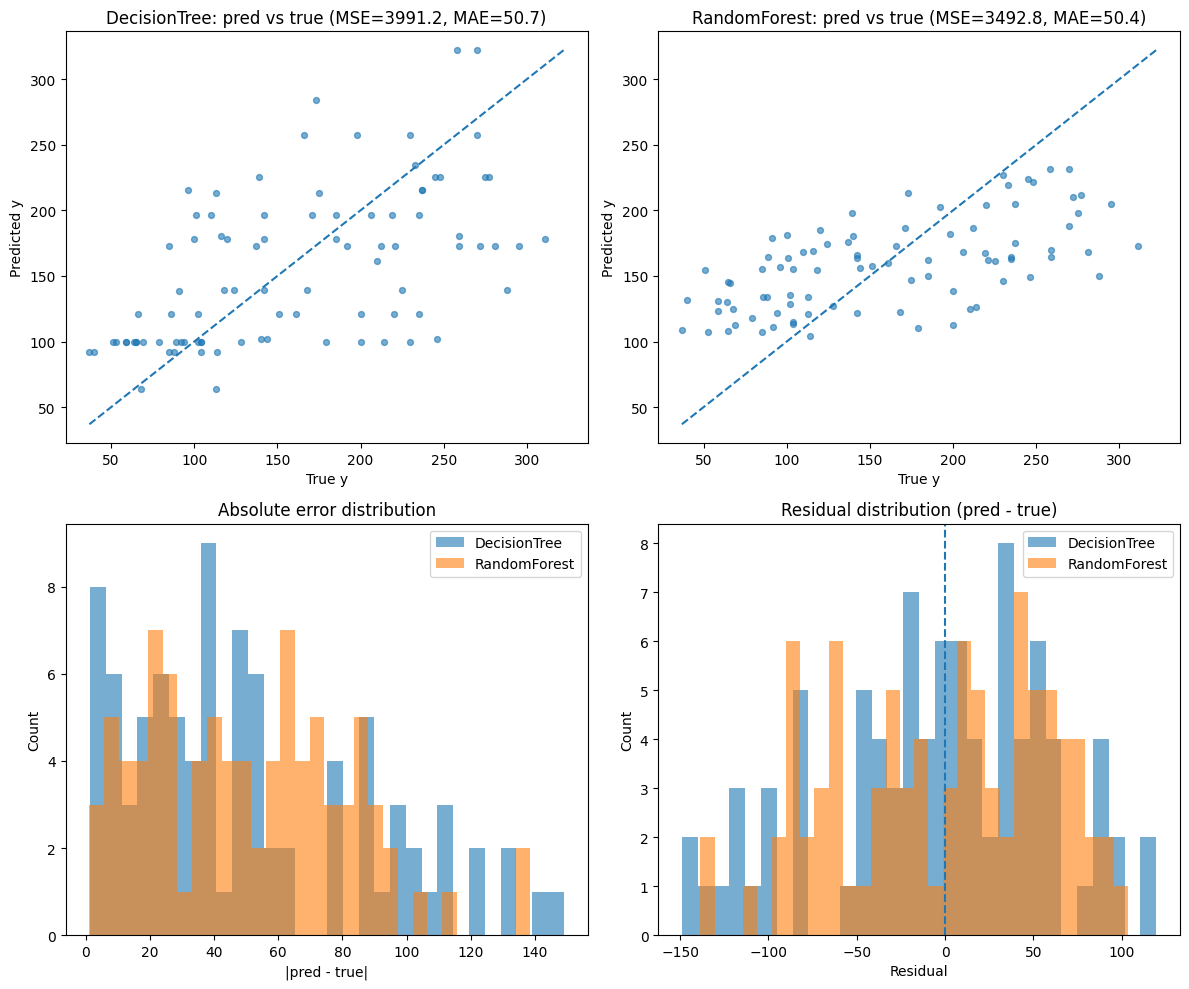

In [19]:
# Visual comparison: outputs + errors (DecisionTree vs RandomForest)
import numpy as np
import matplotlib.pyplot as plt

required = ['y_test', 'tree_preds_test', 'forest_preds_test']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f'Missing variables: {missing}. Re-run the evaluation cell that creates y_test/tree_preds_test/forest_preds_test.')

y_true = np.asarray(y_test, dtype=float)
y_dt = np.asarray(tree_preds_test, dtype=float)
y_rf = np.asarray(forest_preds_test, dtype=float)

dt_resid = y_dt - y_true
rf_resid = y_rf - y_true
dt_abs = np.abs(dt_resid)
rf_abs = np.abs(rf_resid)

def _mse(a, b):
    return float(np.mean((a - b) ** 2))

def _mae(a, b):
    return float(np.mean(np.abs(a - b)))

dt_mse, dt_mae = _mse(y_true, y_dt), _mae(y_true, y_dt)
rf_mse, rf_mae = _mse(y_true, y_rf), _mae(y_true, y_rf)

vmin = float(min(y_true.min(), y_dt.min(), y_rf.min()))
vmax = float(max(y_true.max(), y_dt.max(), y_rf.max()))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
(ax1, ax2), (ax3, ax4) = axes

# Predicted vs True scatter
ax1.scatter(y_true, y_dt, s=18, alpha=0.6)
ax1.plot([vmin, vmax], [vmin, vmax], linestyle='--')
ax1.set_title(f'DecisionTree: pred vs true (MSE={dt_mse:.1f}, MAE={dt_mae:.1f})')
ax1.set_xlabel('True y')
ax1.set_ylabel('Predicted y')

ax2.scatter(y_true, y_rf, s=18, alpha=0.6)
ax2.plot([vmin, vmax], [vmin, vmax], linestyle='--')
ax2.set_title(f'RandomForest: pred vs true (MSE={rf_mse:.1f}, MAE={rf_mae:.1f})')
ax2.set_xlabel('True y')
ax2.set_ylabel('Predicted y')

# Absolute error histograms
bins = 30
ax3.hist(dt_abs, bins=bins, alpha=0.6, label='DecisionTree')
ax3.hist(rf_abs, bins=bins, alpha=0.6, label='RandomForest')
ax3.set_title('Absolute error distribution')
ax3.set_xlabel('|pred - true|')
ax3.set_ylabel('Count')
ax3.legend()

# Residual histograms
ax4.hist(dt_resid, bins=bins, alpha=0.6, label='DecisionTree')
ax4.hist(rf_resid, bins=bins, alpha=0.6, label='RandomForest')
ax4.axvline(0.0, linestyle='--')
ax4.set_title('Residual distribution (pred - true)')
ax4.set_xlabel('Residual')
ax4.set_ylabel('Count')
ax4.legend()

plt.tight_layout()
plt.show()